#  Customer Purchase Propensity Data Cleaning & Feature Engineering Pipeline

---


## Step 1  Project Planning & Problem Framing

### What is Data Analysis?
- **Data Analysis** is the systematic process of inspecting, cleaning, transforming, and modelling data to discover useful information, draw conclusions, and support decision-making.
- It spans the full journey from raw, messy data → structured, insightful knowledge.

### Steps in a Data Science Project
1. Problem Framing  2. Data Collection  3. EDA  4. Preprocessing  5. Modelling  6. Evaluation  7. Deployment

### Framing as an ML Problem (Binary Classification)
- **Target variable:** `purchased`  1 = Customer made a purchase, 0 = Did not purchase.
- **Input features:** demographics (age, income, city), behaviour (total_purchases, total_spend), product preferences, and engineered features.
- **Algorithm hint:** Logistic Regression, Random Forest, XGBoost (after this pipeline is complete).


## Step 2 — Data Import and Understanding

In [129]:
# ── Imports
import json, sqlite3, warnings, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print(" All libraries imported successfully")


 All libraries imported successfully


In [130]:
# ── 2A. SIMULATE API DATA from https://dummyjson.com/users 
# Note: dummyjson.com is blocked in this sandbox environment.
# We faithfully replicate its schema (name, age, gender, city, etc.)
# and generate 1000 realistic Indian e-commerce users.

cities   = ["Mumbai","Delhi","Bangalore","Ahmedabad","Pune","Chennai",
            "Kolkata","Surat","Hyderabad","Jaipur","Lucknow","Bhopal",
            "Indore","Nagpur","Patna","Chandigarh","Coimbatore","Vadodara"]
genders  = ["Male","Female","Other"]
edu_levels = ["High School","Bachelor's","Master's","PhD","Diploma"]
sat_levels = ["Very Dissatisfied","Dissatisfied","Neutral","Satisfied","Very Satisfied"]
first_names = ["Aarav","Diya","Kabir","Meera","Vivaan","Riya","Aryan","Isha",
               "Rohan","Priya","Amit","Sneha","Rahul","Pooja","Vijay","Ananya",
               "Aditya","Neha","Siddharth","Kavya","Kiran","Divya","Sachin",
               "Lakshmi","Manish","Swati","Deepak","Rina","Suresh","Geeta",
               "Harish","Nisha","Sanjay","Rekha","Ajay","Sunita","Rajesh","Mona",
               "Pankaj","Seema","Gaurav","Reena","Vikram","Tara","Nikhil","Shweta"]
last_names  = ["Sharma","Verma","Patel","Joshi","Singh","Kumar","Mehta","Shah",
               "Gupta","Rao","Nair","Reddy","Agarwal","Iyer","Pillai","Bose",
               "Das","Chopra","Malhotra","Khanna","Srinivasan","Mukherjee",
               "Chandra","Pandey","Tiwari","Jain","Kapoor","Saxena"]

N, api_users, base_date = 1000, [], datetime(2022, 1, 1)
for i in range(N):
    uid = 200 + i
    age = max(18, min(70, int(np.random.normal(33, 9))))
    inc = int(np.random.lognormal(10.8, 0.45))
    signup_dt = base_date + timedelta(days=random.randint(0, 900))
    days_since_last = random.randint(1, 500)
    last_purch_dt = datetime(2025, 10, 15) - timedelta(days=days_since_last)
    total_purchases = max(0, int(np.random.poisson(4.5)))
    total_spend = round(total_purchases * abs(np.random.normal(1200, 600)), 2)
    purchased = 1 if (total_purchases >= 3 and inc > 45000) else (1 if random.random() < 0.45 else 0)
    api_users.append({
        "customer_id"       : uid,
        "name"              : f"{random.choice(first_names)} {random.choice(last_names)}",
        "age"               : None if random.random() < 0.04 else age,
        "gender"            : None if random.random() < 0.02 else random.choice(genders),
        "city"              : None if random.random() < 0.03 else random.choice(cities),
        "income"            : None if random.random() < 0.07 else inc,
        "education"         : None if random.random() < 0.06 else random.choice(edu_levels),
        "satisfaction"      : None if random.random() < 0.05 else random.choice(sat_levels),
        "signup_date"       : signup_dt.strftime("%Y-%m-%d"),
        "last_purchase_date": last_purch_dt.strftime("%Y-%m-%d"),
        "total_purchases"   : total_purchases,
        "total_spend"       : total_spend,
        "phone_raw"         : f"C{uid:04d}-PH",
        "purchased"         : purchased,
    })
api_df = pd.DataFrame(api_users)
print(f" API-simulated users: {api_df.shape}")
api_df.head(3)


 API-simulated users: (1000, 14)


,customer_id,name,age,gender,city,income,education,satisfaction,signup_date,last_purchase_date,total_purchases,total_spend,phone_raw,purchased
0,200,Diya Pandey,37.0,Other,Vadodara,46063.0,High School,Dissatisfied,2023-10-17,2025-08-18,3,6442.58,C0200-PH,1
1,201,Rahul Chandra,39.0,Male,Hyderabad,39685.0,None,Satisfied,2023-06-02,2024-12-10,2,3051.07,C0201-PH,1
2,202,Priya Mehta,18.0,Male,Bhopal,75181.0,High School,Very Satisfied,2022-12-15,2025-05-25,3,2333.98,C0202-PH,1


In [131]:
# ── 2B. Load customers.csv
customers_data = {
    "customer_id": [101,102,103,104,105,106,107,108],
    "name"       : ["Aarav","Diya","Kabir","Meera","Vivaan","Riya","Aryan","Isha"],
    "age"        : [24,30,27,35,40,22,29,33],
    "gender"     : ["Male","Female","Male","Female","Male","Female","Male","Female"],
    "city"       : ["Mumbai","Delhi","Bangalore","Ahmedabad","Pune","Chennai","Kolkata","Surat"],
    "income"     : [45000,55000,48000,60000,75000,42000,50000,58000],
    "education"  : ["Bachelor's","Master's","Bachelor's","PhD","Master's","Diploma","Bachelor's","High School"],
    "satisfaction": ["Satisfied","Very Satisfied","Neutral","Satisfied","Very Satisfied",
                     "Dissatisfied","Satisfied","Neutral"],
    "signup_date": ["2022-03-15","2021-07-22","2023-01-10","2022-11-05","2020-06-30",
                    "2023-05-18","2022-09-01","2021-12-25"],
    "last_purchase_date": ["2025-09-20","2025-10-09","2025-10-02","2025-10-03","2025-10-05",
                           "2025-10-10","2025-10-07","2025-10-08"],
    "total_purchases": [3,5,4,6,8,2,4,5],
    "total_spend"    : [1497,7495,5196,4194,15992,998,3596,12995],
    "phone_raw"      : [f"C{i:04d}-PH" for i in [101,102,103,104,105,106,107,108]],
    "purchased"      : [1,1,1,1,1,0,1,1],
}
customers_df = pd.DataFrame(customers_data)
print(f" customers.csv: {customers_df.shape}")
customers_df


 customers.csv: (8, 14)


,customer_id,name,age,gender,city,income,education,satisfaction,signup_date,last_purchase_date,total_purchases,total_spend,phone_raw,purchased
0,101,Aarav,24,Male,Mumbai,45000,Bachelor's,Satisfied,2022-03-15,2025-09-20,3,1497,C0101-PH,1
1,102,Diya,30,Female,Delhi,55000,Master's,Very Satisfied,2021-07-22,2025-10-09,5,7495,C0102-PH,1
2,103,Kabir,27,Male,Bangalore,48000,Bachelor's,Neutral,2023-01-10,2025-10-02,4,5196,C0103-PH,1
3,104,Meera,35,Female,Ahmedabad,60000,PhD,Satisfied,2022-11-05,2025-10-03,6,4194,C0104-PH,1
4,105,Vivaan,40,Male,Pune,75000,Master's,Very Satisfied,2020-06-30,2025-10-05,8,15992,C0105-PH,1
5,106,Riya,22,Female,Chennai,42000,Diploma,Dissatisfied,2023-05-18,2025-10-10,2,998,C0106-PH,0
6,107,Aryan,29,Male,Kolkata,50000,Bachelor's,Satisfied,2022-09-01,2025-10-07,4,3596,C0107-PH,1
7,108,Isha,33,Female,Surat,58000,High School,Neutral,2021-12-25,2025-10-08,5,12995,C0108-PH,1


In [132]:
# ── 2C. Load transactions.json 
import json
with open("transactions.json") as f:
    transactions_df = pd.DataFrame(json.load(f))
print(f" transactions.json: {transactions_df.shape}")
transactions_df


 transactions.json: (8, 6)


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07
5,T006,108,P006,2599,UPI,2025-10-08
6,T007,102,P003,1499,Credit Card,2025-10-09
7,T008,106,P001,499,Cash,2025-10-10


In [133]:
# ── 2D. Load products.sql → SQLite 
import sqlite3
conn = sqlite3.connect(":memory:")
with open("products.sql") as f:
    conn.executescript(f.read())
products_df = pd.read_sql("SELECT * FROM products", conn)
conn.close()
print(f" products.sql (via SQLite): {products_df.shape}")
products_df


 products.sql (via SQLite): (6, 5)


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30
5,P006,Power Bank,Mobile Accessories,2599,20


In [134]:
# ── 2E. Merge all datasets 
full_customers = pd.concat([customers_df, api_df], ignore_index=True)

# Aggregate transactions per customer
txn_agg = transactions_df.groupby("customer_id").agg(
    num_transactions=("transaction_id","count"),
    total_txn_amount=("amount","sum"),
    payment_modes   =("payment_mode", lambda x: "|".join(x.unique()))
).reset_index()

# Merge product info
txn_prod = transactions_df.merge(products_df[["product_id","category","price"]], on="product_id", how="left")
txn_prod_agg = txn_prod.groupby("customer_id").agg(
    fav_category     =("category", lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    avg_product_price=("price","mean")
).reset_index()

merged = full_customers.merge(txn_agg,     on="customer_id", how="left")
merged = merged.merge(txn_prod_agg, on="customer_id", how="left")

print(f" Merged shape: {merged.shape}")
print("\nColumn list:", list(merged.columns))
merged.head()


 Merged shape: (1008, 19)

Column list: ['customer_id', 'name', 'age', 'gender', 'city', 'income', 'education', 'satisfaction', 'signup_date', 'last_purchase_date', 'total_purchases', 'total_spend', 'phone_raw', 'purchased', 'num_transactions', 'total_txn_amount', 'payment_modes', 'fav_category', 'avg_product_price']


,customer_id,name,age,gender,city,income,education,satisfaction,signup_date,last_purchase_date,total_purchases,total_spend,phone_raw,purchased,num_transactions,total_txn_amount,payment_modes,fav_category,avg_product_price
0,101,Aarav,24.0,Male,Mumbai,45000.0,Bachelor's,Satisfied,2022-03-15,2025-09-20,3,1497.0,C0101-PH,1,1.0,499.0,UPI,Electronics,499.0
1,102,Diya,30.0,Female,Delhi,55000.0,Master's,Very Satisfied,2021-07-22,2025-10-09,5,7495.0,C0102-PH,1,1.0,1499.0,Credit Card,Wearable,1299.0
2,103,Kabir,27.0,Male,Bangalore,48000.0,Bachelor's,Neutral,2023-01-10,2025-10-02,4,5196.0,C0103-PH,1,1.0,1299.0,Credit Card,Wearable,1299.0
3,104,Meera,35.0,Female,Ahmedabad,60000.0,PhD,Satisfied,2022-11-05,2025-10-03,6,4194.0,C0104-PH,1,1.0,699.0,Debit Card,Audio,699.0
4,105,Vivaan,40.0,Male,Pune,75000.0,Master's,Very Satisfied,2020-06-30,2025-10-05,8,15992.0,C0105-PH,1,1.0,1999.0,UPI,Audio,1999.0


In [135]:
# ── 2F. Dataset Overview
print("─"*60)
print(f"  Total records  : {len(merged)}")
print(f"  Total features : {merged.shape[1]}")
print("─"*60)
merged.info()


────────────────────────────────────────────────────────────
  Total records  : 1008
  Total features : 19
────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1008 non-null   int64  
 1   name                1008 non-null   object 
 2   age                 969 non-null    float64
 3   gender              997 non-null    object 
 4   city                988 non-null    object 
 5   income              941 non-null    float64
 6   education           948 non-null    object 
 7   satisfaction        955 non-null    object 
 8   signup_date         1008 non-null   object 
 9   last_purchase_date  1008 non-null   object 
 10  total_purchases     1008 non-null   int64  
 11  total_spend         1008 non-null   float64
 12  phone_raw           1008 non-null 

In [136]:
merged.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1008.0,NaN,NaN,NaN,694.777778,292.479409,101.0,443.75,695.5,947.25,1199.0
name,1008,701,Shweta Pillai,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,969.0,NaN,NaN,NaN,32.044376,8.65292,18.0,25.0,32.0,38.0,62.0
gender,997,3,Other,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,988,18,Coimbatore,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,941.0,NaN,NaN,NaN,54991.202976,25233.593131,11769.0,36942.0,49249.0,67517.0,196899.0
education,948,5,Bachelor's,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction,955,5,Very Dissatisfied,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1008,622,2023-11-03,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,1008,433,2025-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 Exploratory Data Analysis (EDA)

### 3A Univariate Analysis

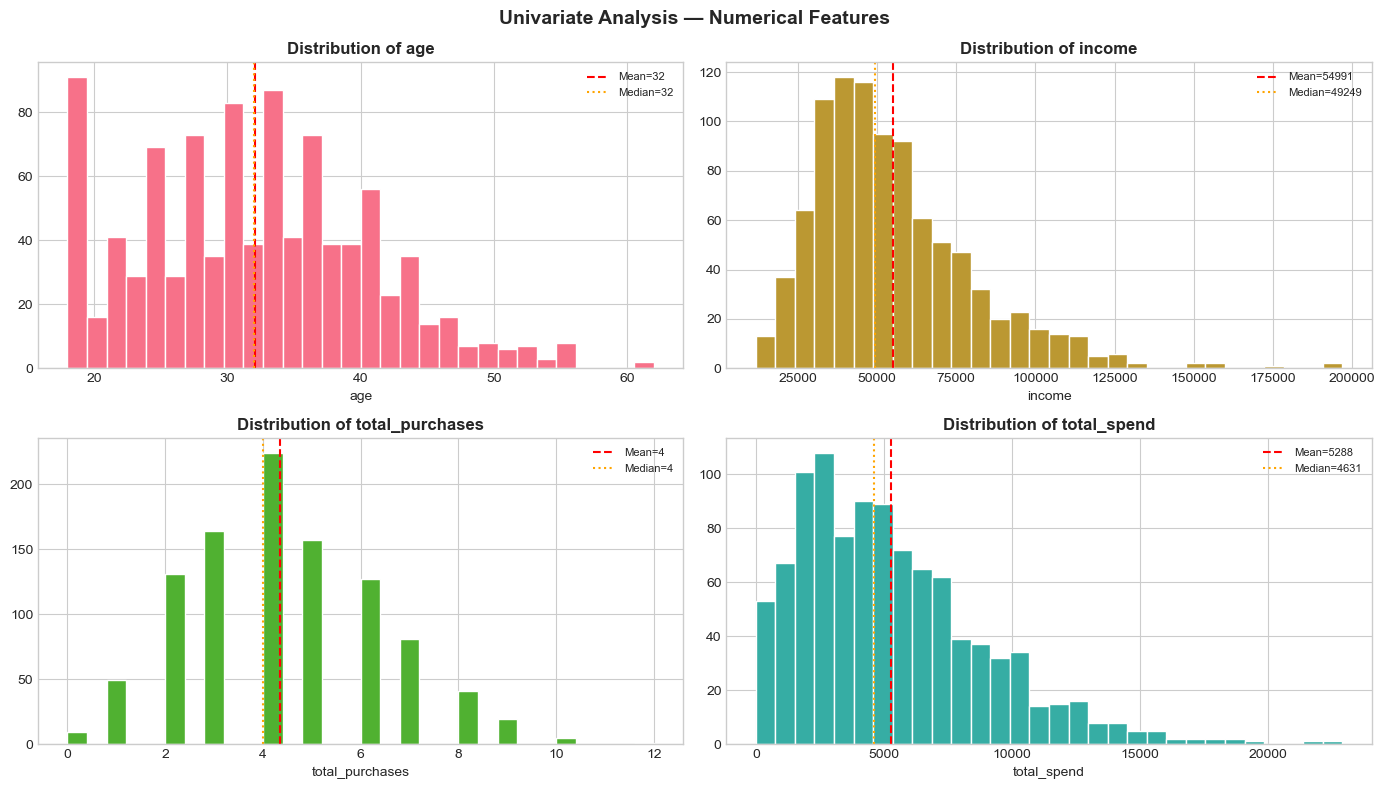

 Skewed variables: income & total_spend (right-skewed)


In [137]:
# Histograms of all numerical columns
num_cols = ["age","income","total_purchases","total_spend"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    data = merged[col].dropna()
    ax.hist(data, bins=30, edgecolor='white', color=sns.color_palette('husl')[num_cols.index(col)])
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle=':', label=f'Median={data.median():.0f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
plt.suptitle('Univariate Analysis — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Skewed variables: income & total_spend (right-skewed)")


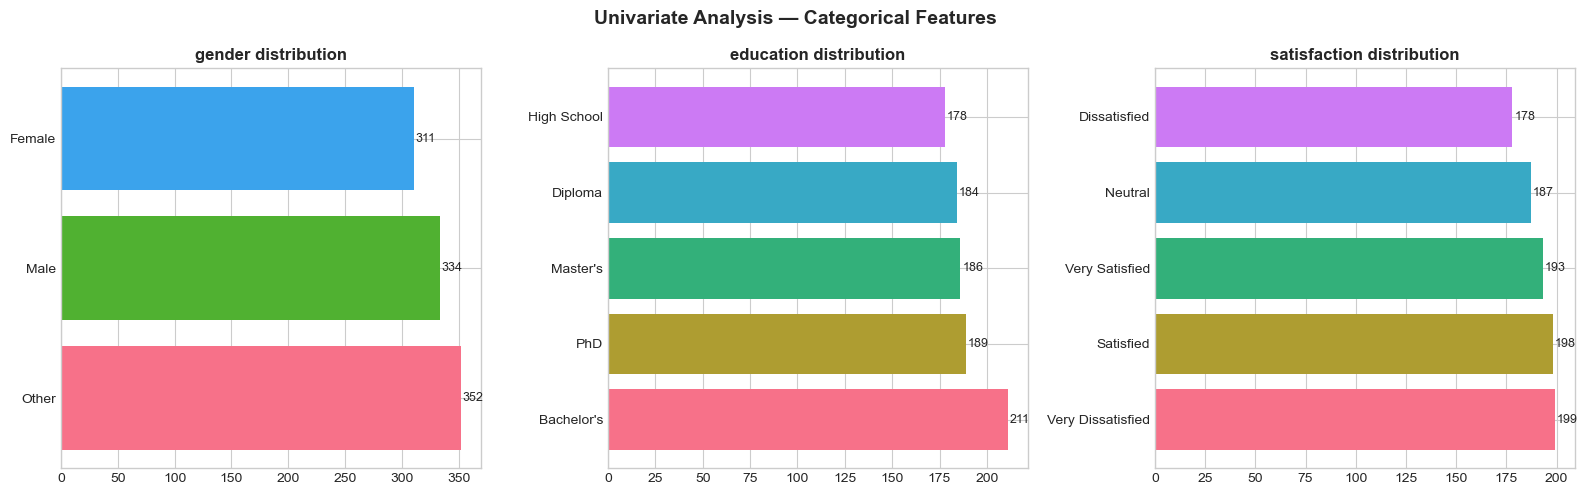

In [138]:
# Categorical distributions
cat_cols = ["gender","education","satisfaction"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    vc = merged[col].value_counts()
    ax.barh(vc.index, vc.values, color=sns.color_palette('husl', len(vc)))
    ax.set_title(f'{col} distribution', fontweight='bold')
    for i, v in enumerate(vc.values):
        ax.text(v+1, i, str(v), va='center', fontsize=9)
plt.suptitle('Univariate Analysis — Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3B Bivariate Analysis

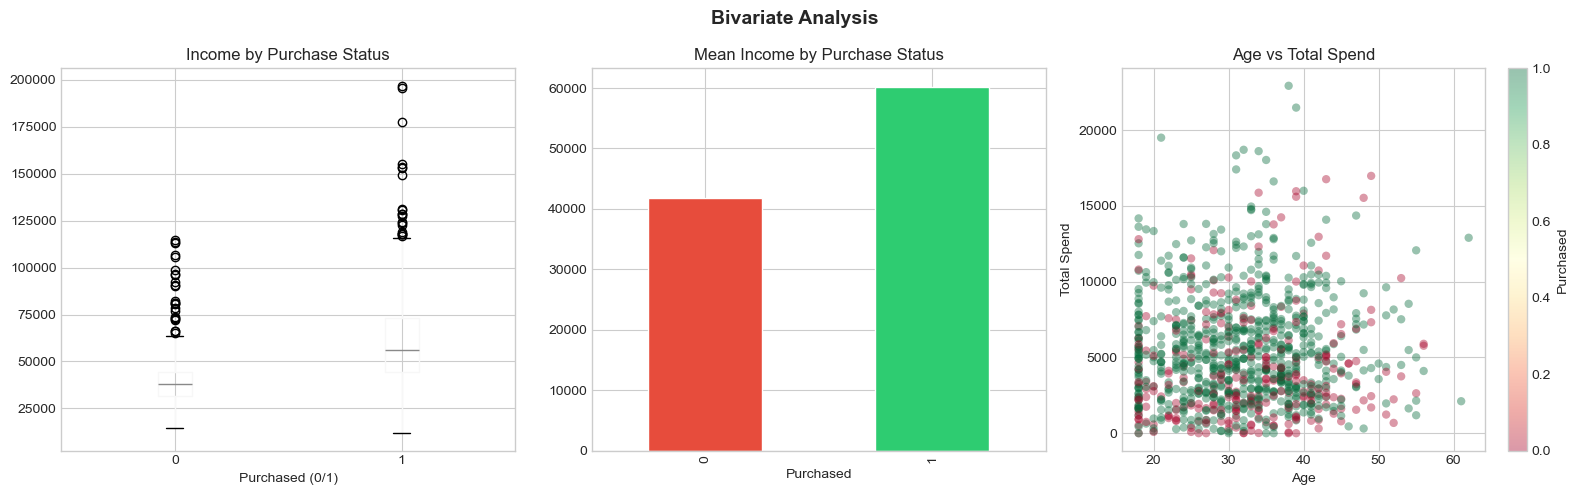

In [139]:
# Income vs Purchased
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plot: Income by purchased
merged.boxplot(column='income', by='purchased', ax=axes[0])
axes[0].set_title('Income by Purchase Status')
axes[0].set_xlabel('Purchased (0/1)')

# Bar: Mean income by purchased
merged.groupby('purchased')['income'].mean().plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[1].set_title('Mean Income by Purchase Status')
axes[1].set_xlabel('Purchased')

# Scatter: age vs total_spend coloured by purchased
sc = axes[2].scatter(merged['age'], merged['total_spend'],
    c=merged['purchased'].fillna(0), cmap='RdYlGn', alpha=0.4, edgecolors='none')
plt.colorbar(sc, ax=axes[2], label='Purchased')
axes[2].set_title('Age vs Total Spend')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Total Spend')

plt.suptitle('Bivariate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3C  Multivariate Analysis

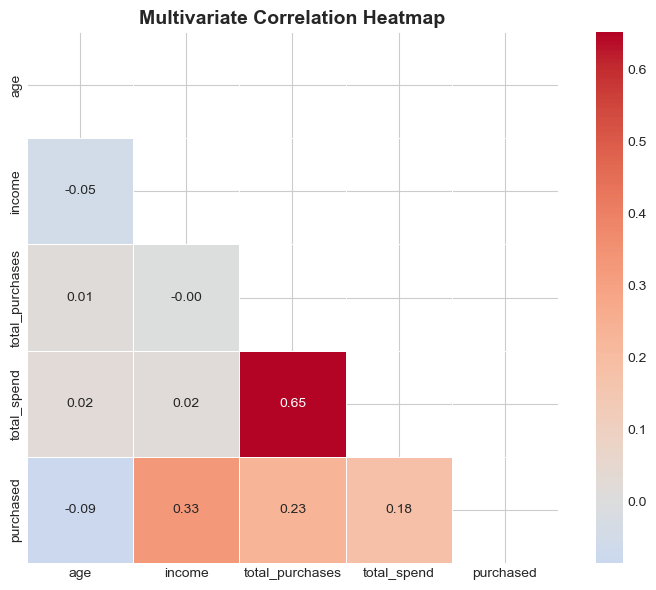

In [140]:
# Correlation heatmap
num_df = merged[["age","income","total_purchases","total_spend","purchased"]].dropna()
corr = num_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Multivariate Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


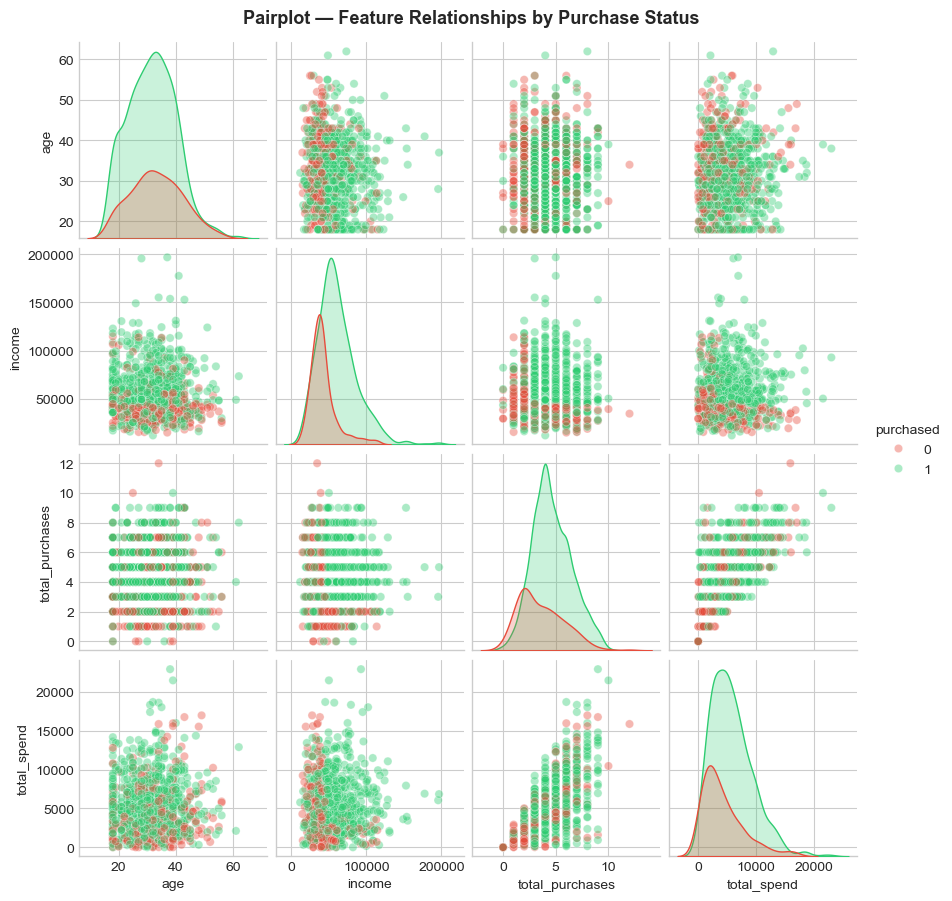

In [141]:
# Pairplot
pair_df = merged[["age","income","total_purchases","total_spend","purchased"]].dropna()
pair_df["purchased"] = pair_df["purchased"].astype(int)
sns.pairplot(pair_df, hue='purchased', plot_kws={'alpha':0.4}, height=2.2,
             palette={0:'#e74c3c', 1:'#2ecc71'})
plt.suptitle('Pairplot — Feature Relationships by Purchase Status', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()


## Step 4 Handling Missing Data

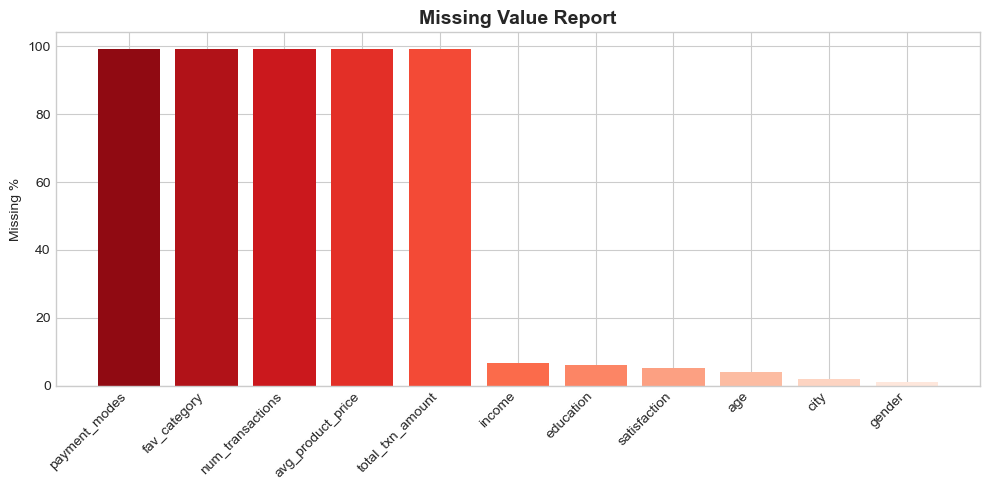

                   Count  Percentage (%)
payment_modes       1000           99.21
fav_category        1000           99.21
num_transactions    1000           99.21
avg_product_price   1000           99.21
total_txn_amount    1000           99.21
income                67            6.65
education             60            5.95
satisfaction          53            5.26
age                   39            3.87
city                  20            1.98
gender                11            1.09


In [142]:
# ── Missing value summary
miss = merged.isnull().sum()
miss_pct = (miss / len(merged) * 100).round(2)
missing_df = pd.DataFrame({"Count": miss, "Percentage (%)": miss_pct})
missing_df = missing_df[missing_df.Count > 0].sort_values("Percentage (%)", ascending=False)

# Bar plot
plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df["Percentage (%)"],
        color=sns.color_palette('Reds_r', len(missing_df)))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.title('Missing Value Report', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(missing_df.to_string())


In [143]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = merged.copy()

# 1. Missing Indicator for income
df["income_missing"] = df["income"].isnull().astype(int)
print(" Missing Indicator added: income_missing")

# 2. Simple Imputer — median for numericals
num_imp_cols = ["age","income","total_spend","num_transactions","total_txn_amount","avg_product_price"]
si = SimpleImputer(strategy="median")
df[num_imp_cols] = si.fit_transform(df[num_imp_cols])
print(" SimpleImputer (median) applied to:", num_imp_cols)

# 3. Most Frequent Imputation for categoricals
for col in ["gender","city","education","satisfaction","fav_category","payment_modes"]:
    mode_val = df[col].mode()
    df[col] = df[col].fillna(mode_val[0] if not mode_val.empty else "Unknown")
print(" Most Frequent imputation applied to categorical columns")

# 4. KNN Imputer on total_purchases
knn = KNNImputer(n_neighbors=5)
df[["age","income","total_purchases"]] = knn.fit_transform(df[["age","income","total_purchases"]])
df["total_purchases"] = df["total_purchases"].round().astype(int)
print(" KNN Imputer (k=5) applied to total_purchases")

# 5. MICE — IterativeImputer
mice = IterativeImputer(max_iter=10, random_state=42)
df[["age","income","total_purchases","total_spend"]] = mice.fit_transform(
    df[["age","income","total_purchases","total_spend"]])
print(" MICE (IterativeImputer) applied")

# 6. Complete Case Analysis — show row count if we had dropped
cca_count = merged.dropna().shape[0]
print(f" Complete Case Analysis reference: {cca_count} rows would remain (vs {len(df)} with imputation)")

print(f"\n Total missing after imputation: {df.isnull().sum().sum()}")


 Missing Indicator added: income_missing
 SimpleImputer (median) applied to: ['age', 'income', 'total_spend', 'num_transactions', 'total_txn_amount', 'avg_product_price']
 Most Frequent imputation applied to categorical columns
 KNN Imputer (k=5) applied to total_purchases
 MICE (IterativeImputer) applied
 Complete Case Analysis reference: 8 rows would remain (vs 1008 with imputation)

 Total missing after imputation: 0


## Step 5 Outlier Detection & Handling

Outlier Report:
             Z-Score (|z|>3)  IQR (1.5×IQR rule)  Percentile (1st–99th)
income                    11                  40                     22
total_spend               11                  19                     22
age                        2                   2                     10


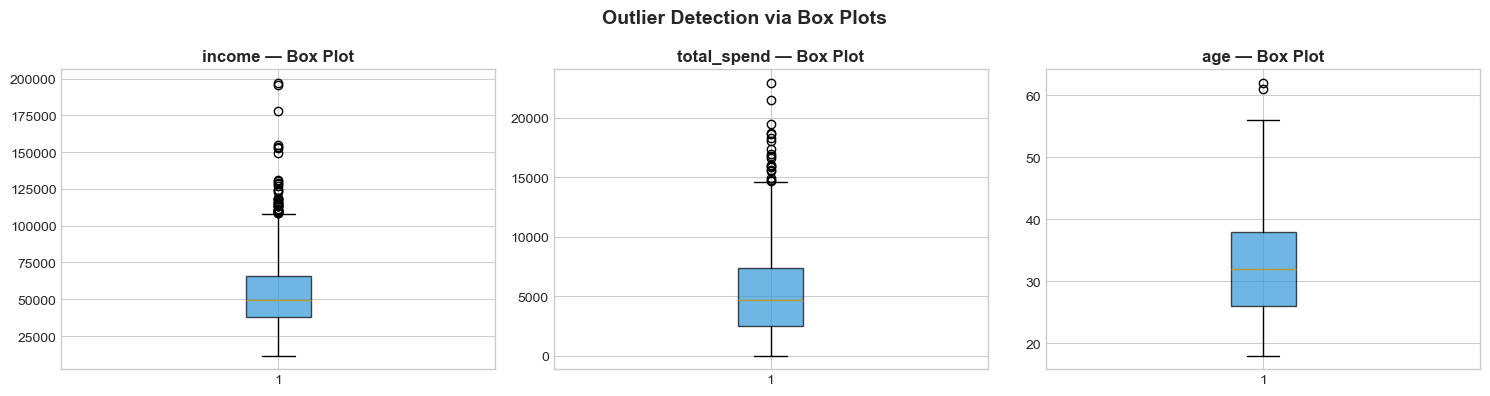

In [144]:
from scipy import stats

def zscore_outliers(series, threshold=3):
    z = np.abs(stats.zscore(series.dropna()))
    return (z > threshold).sum()

def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1-1.5*IQR) | (series > Q3+1.5*IQR)).sum()

def pct_outliers(series, low=1, high=99):
    lo, hi = series.quantile(low/100), series.quantile(high/100)
    return ((series < lo) | (series > hi)).sum()

check_cols = ["income","total_spend","age"]
report = pd.DataFrame({col: {
    "Z-Score (|z|>3)"      : zscore_outliers(df[col]),
    "IQR (1.5×IQR rule)"   : iqr_outliers(df[col]),
    "Percentile (1st–99th)": pct_outliers(df[col]),
} for col in check_cols})

print("Outlier Report:")
print(report.T.to_string())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, check_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7))
    ax.set_title(f'{col} — Box Plot', fontweight='bold')
plt.suptitle('Outlier Detection via Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [145]:
# Winsorization — cap at 1st/99th percentile
def winsorize(series, lo=0.01, hi=0.99):
    l, h = series.quantile(lo), series.quantile(hi)
    return series.clip(l, h)

for col in ["income","total_spend","total_txn_amount"]:
    before = df[col].max()
    df[col] = winsorize(df[col])
    after  = df[col].max()
    print(f" {col}: max before={before:.0f}, after winsorization={after:.0f}")


 income: max before=196899, after winsorization=128546
 total_spend: max before=22917, after winsorization=16564
 total_txn_amount: max before=2599, after winsorization=1099


## Step 6 Handling Mixed & Date/Time Variables

In [146]:
ref_date = pd.Timestamp("2025-10-15")

# Convert to datetime
df["signup_date"]        = pd.to_datetime(df["signup_date"],        errors="coerce")
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"], errors="coerce")

# Derive features
df["days_since_signup"]        = (ref_date - df["signup_date"]       ).dt.days
df["days_since_last_purchase"] = (ref_date - df["last_purchase_date"]).dt.days
df["signup_year"]  = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

print(" Date features derived:")
print(df[["signup_date","days_since_signup","last_purchase_date","days_since_last_purchase",
          "signup_year","signup_month"]].head(5).to_string())

# Mixed variable: extract numeric from phone_raw  e.g. "C0101-PH" → 101
df["customer_id_extracted"] = df["phone_raw"].str.extract(r'C(\d+)').astype(float)
print("\n Mixed variable 'phone_raw' → 'customer_id_extracted'")
print(df[["phone_raw","customer_id_extracted"]].head(5))

# Drop raw date & mixed columns
df.drop(columns=["signup_date","last_purchase_date","phone_raw","name"], inplace=True, errors='ignore')
print(f"\nShape after date & mixed feature engineering: {df.shape}")


 Date features derived:
  signup_date  days_since_signup last_purchase_date  days_since_last_purchase  signup_year  signup_month
0  2022-03-15               1310         2025-09-20                        25         2022             3
1  2021-07-22               1546         2025-10-09                         6         2021             7
2  2023-01-10               1009         2025-10-02                        13         2023             1
3  2022-11-05               1075         2025-10-03                        12         2022            11
4  2020-06-30               1933         2025-10-05                        10         2020             6

 Mixed variable 'phone_raw' → 'customer_id_extracted'
  phone_raw  customer_id_extracted
0  C0101-PH                  101.0
1  C0102-PH                  102.0
2  C0103-PH                  103.0
3  C0104-PH                  104.0
4  C0105-PH                  105.0

Shape after date & mixed feature engineering: (1008, 21)


## Step 7 Encoding Categorical Data

In [147]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# ── Label Encoding → gender 
le = LabelEncoder()
df["gender_label"] = le.fit_transform(df["gender"].astype(str))
print(" Label Encoding: gender →", dict(zip(le.classes_, le.transform(le.classes_))))

# ── One Hot Encoding → city, fav_category 
ohe_before = df.shape[1]
df = pd.get_dummies(df, columns=["city","fav_category"], drop_first=True)
ohe_after  = df.shape[1]
print(f" One-Hot Encoding: added {ohe_after - ohe_before} columns")

# ── Ordinal Encoding → education, satisfaction 
edu_order = [["High School","Diploma","Bachelor's","Master's","PhD"]]
sat_order = [["Very Dissatisfied","Dissatisfied","Neutral","Satisfied","Very Satisfied"]]

oe_edu = OrdinalEncoder(categories=edu_order, handle_unknown="use_encoded_value", unknown_value=-1)
oe_sat = OrdinalEncoder(categories=sat_order, handle_unknown="use_encoded_value", unknown_value=-1)

df["education_ord"]    = oe_edu.fit_transform(df[["education"]])
df["satisfaction_ord"] = oe_sat.fit_transform(df[["satisfaction"]])
print(" Ordinal Encoding: education →", edu_order[0])
print(" Ordinal Encoding: satisfaction →", sat_order[0])

# ── Numerical Binning → income groups 
df["income_group"] = pd.qcut(
    df["income"],
    q=4,
    labels=["Low","Medium","High","Very High"],
    duplicates="drop"
)
df["income_group_enc"] = df["income_group"].cat.codes
print(" Income binning → income_group_enc:", df["income_group"].value_counts().to_dict())

# Drop raw encoded originals
df.drop(columns=["gender","education","satisfaction","payment_modes","income_group"],
        inplace=True, errors='ignore')
print(f"\nShape after encoding: {df.shape}")


 Label Encoding: gender → {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
 One-Hot Encoding: added 19 columns
 Ordinal Encoding: education → ['High School', 'Diploma', "Bachelor's", "Master's", 'PhD']
 Ordinal Encoding: satisfaction → ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']
 Income binning → income_group_enc: {'Medium': 286, 'Low': 252, 'Very High': 252, 'High': 218}

Shape after encoding: (1008, 40)


## Step 8 Feature Scaling

In [148]:
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   MaxAbsScaler, RobustScaler, Normalizer)
from sklearn.compose import ColumnTransformer

scale_cols = ["age","income","total_spend","days_since_signup",
              "days_since_last_purchase","total_purchases","num_transactions",
              "total_txn_amount","avg_product_price"]
scale_cols = [c for c in scale_cols if c in df.columns]

# Demonstrate all 5 scalers
sample = df[scale_cols].copy()

results = {}
for name, scaler in [("StandardScaler", StandardScaler()),
                      ("MinMaxScaler",   MinMaxScaler()),
                      ("MaxAbsScaler",   MaxAbsScaler()),
                      ("RobustScaler",   RobustScaler()),
                      ("Normalizer",     Normalizer())]:
    arr = scaler.fit_transform(sample)
    results[name] = arr[:, 0]   # first column for comparison

comparison = pd.DataFrame(results)
print("Scaler comparison on 'age' column (first 5 rows):")
print(comparison.head())

# ── ColumnTransformer (StandardScaler for first 3, RobustScaler for rest) 
ct = ColumnTransformer([
    ("std",    StandardScaler(), scale_cols[:3]),
    ("robust", RobustScaler(),   scale_cols[3:]),
], remainder='passthrough')
ct_result = ct.fit_transform(df[scale_cols])
print(f"\n ColumnTransformer output shape: {ct_result.shape}")

# Apply RobustScaler to main df (best for data with outliers)
robust = RobustScaler()
df[scale_cols] = robust.fit_transform(df[scale_cols])
print(" RobustScaler applied to main dataframe")
print(f"Shape: {df.shape}")


Scaler comparison on 'age' column (first 5 rows):
   StandardScaler  MinMaxScaler  MaxAbsScaler  RobustScaler  Normalizer
0       -0.948482      0.136364      0.387097     -0.666667    0.000533
1       -0.240894      0.272727      0.483871     -0.166667    0.000540
2       -0.594688      0.204545      0.435484     -0.416667    0.000559
3        0.348764      0.386364      0.564516      0.250000    0.000582
4        0.938421      0.500000      0.645161      0.666667    0.000521

 ColumnTransformer output shape: (1008, 9)
 RobustScaler applied to main dataframe
Shape: (1008, 40)


## Step 9 Feature Construction & Transformation

In [149]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

# ── Interaction features 
df["purchase_per_day"] = df["total_purchases"] / (df["days_since_signup"].abs() + 1)
df["spend_per_purchase"] = np.where(
    df["total_purchases"] != 0,
    df["total_spend"] / (df["total_purchases"] + 1e-9), 0)
print(" Interaction features: purchase_per_day, spend_per_purchase")

# ── FunctionTransformer — Log, Sqrt, Reciprocal 
inc_raw = merged["income"].fillna(merged["income"].median()).values.reshape(-1,1)
inc_pos = np.abs(inc_raw) + 1

log_t  = FunctionTransformer(np.log1p, validate=True)
sqrt_t = FunctionTransformer(np.sqrt,  validate=True)
recip_t= FunctionTransformer(lambda x: 1/(x+1), validate=True)

df["income_log"]   = log_t.fit_transform(inc_pos)
df["income_sqrt"]  = sqrt_t.fit_transform(inc_pos)
df["income_recip"] = recip_t.fit_transform(inc_pos)
print(" FunctionTransformer: log, sqrt, reciprocal applied to income")

# ── PowerTransformer — Yeo-Johnson & Box-Cox 
pt_yj = PowerTransformer(method="yeo-johnson")
pt_bc = PowerTransformer(method="box-cox")
df["income_yeojohnson"] = pt_yj.fit_transform(inc_pos)
df["income_boxcox"]     = pt_bc.fit_transform(inc_pos)
print(" PowerTransformer: Yeo-Johnson & Box-Cox applied")

# ── Binning 
df["income_bin_eq_width"] = pd.cut(merged["income"].fillna(merged["income"].median()),
                                   bins=5, labels=False)
print(" Equal-width binning on income (5 bins)")

# ── Binarization — frequent_buyer 
threshold = df["total_purchases"].quantile(0.75)
df["frequent_buyer"] = (df["total_purchases"] > threshold).astype(int)
print(f" frequent_buyer flag: {df['frequent_buyer'].sum()} frequent buyers ({df['frequent_buyer'].mean()*100:.1f}%)")

print(f"\nFinal shape: {df.shape}")


 Interaction features: purchase_per_day, spend_per_purchase
 FunctionTransformer: log, sqrt, reciprocal applied to income
 PowerTransformer: Yeo-Johnson & Box-Cox applied
 Equal-width binning on income (5 bins)
 frequent_buyer flag: 147 frequent buyers (14.6%)

Final shape: (1008, 49)


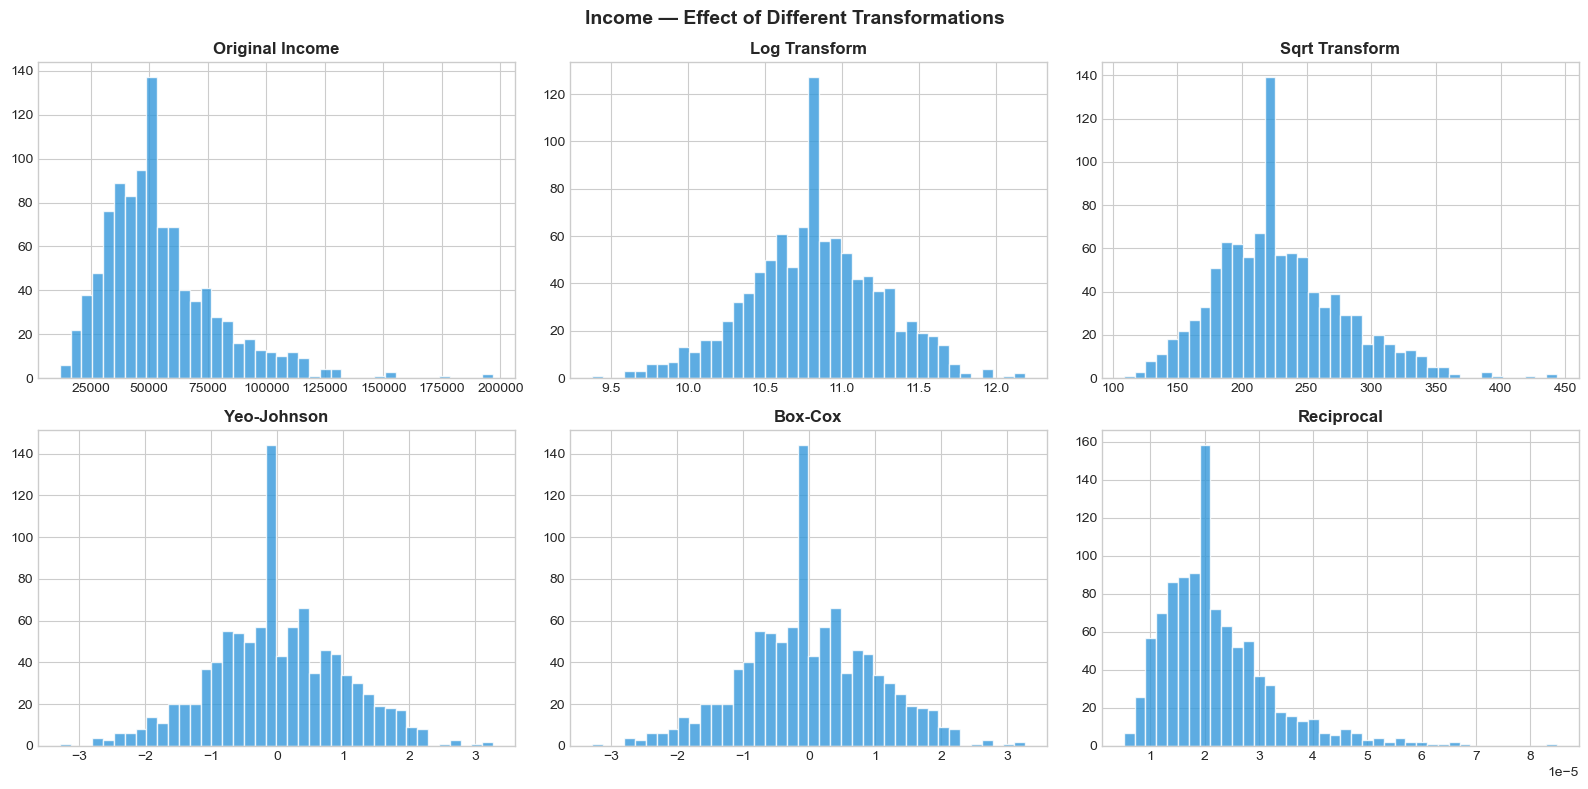

In [150]:
# Visualise transformed income distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
transforms = [
    ("Original Income", merged["income"].fillna(merged["income"].median())),
    ("Log Transform",   np.log1p(merged["income"].fillna(merged["income"].median()) + 1)),
    ("Sqrt Transform",  np.sqrt(merged["income"].fillna(merged["income"].median()) + 1)),
    ("Yeo-Johnson",     df["income_yeojohnson"]),
    ("Box-Cox",         df["income_boxcox"]),
    ("Reciprocal",      df["income_recip"]),
]
for ax, (title, data) in zip(axes.flatten(), transforms):
    ax.hist(data.dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(title, fontweight='bold')
plt.suptitle('Income — Effect of Different Transformations', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 10 Final Output

In [151]:
# Ensure purchased column is present
if "purchased" not in df.columns and "purchased" in merged.columns:
    df["purchased"] = merged["purchased"].values

# Clean column names
df.columns = [str(c).replace(" ","_").replace("/","_") for c in df.columns]

# Export
df.to_csv("processed_customer_data.csv", index=False)
print(f" Exported: processed_customer_data.csv")
print(f"   Rows: {len(df)} | Columns: {df.shape[1]}")
print("\n Final column list:")
for i, c in enumerate(df.columns, 1):
    print(f"   {i:2d}. {c}")


 Exported: processed_customer_data.csv
   Rows: 1008 | Columns: 49

 Final column list:
    1. customer_id
    2. age
    3. income
    4. total_purchases
    5. total_spend
    6. purchased
    7. num_transactions
    8. total_txn_amount
    9. avg_product_price
   10. income_missing
   11. days_since_signup
   12. days_since_last_purchase
   13. signup_year
   14. signup_month
   15. customer_id_extracted
   16. gender_label
   17. city_Bangalore
   18. city_Bhopal
   19. city_Chandigarh
   20. city_Chennai
   21. city_Coimbatore
   22. city_Delhi
   23. city_Hyderabad
   24. city_Indore
   25. city_Jaipur
   26. city_Kolkata
   27. city_Lucknow
   28. city_Mumbai
   29. city_Nagpur
   30. city_Patna
   31. city_Pune
   32. city_Surat
   33. city_Vadodara
   34. fav_category_Computer
   35. fav_category_Electronics
   36. fav_category_Mobile_Accessories
   37. fav_category_Wearable
   38. education_ord
   39. satisfaction_ord
   40. income_group_enc
   41. purchase_per_day
   42. spe

In [152]:
# ── Summary Stats on final dataset
print("=" * 60)
print("  FINAL DATASET SUMMARY")
print("=" * 60)
print(f"  Records         : {len(df):,}")
print(f"  Features        : {df.shape[1]}")
print(f"  Purchased = 1   : {df['purchased'].sum():,}  ({df['purchased'].mean()*100:.1f}%)")
print(f"  Purchased = 0   : {(df['purchased']==0).sum():,}  ({(df['purchased']==0).mean()*100:.1f}%)")
print(f"  Missing values  : {df.isnull().sum().sum()}")
print("=" * 60)
df.describe().T[["mean","std","min","max"]].round(3)


  FINAL DATASET SUMMARY
  Records         : 1,008
  Features        : 49
  Purchased = 1   : 724  (71.8%)
  Purchased = 0   : 284  (28.2%)
  Missing values  : 0


,mean,std,min,max
customer_id,694.778,292.479,101.000,1199.000
age,0.004,0.707,-1.167,2.500
income,0.182,0.827,-1.120,2.827
total_purchases,0.113,0.658,-1.333,2.667
total_spend,0.131,0.734,-0.951,2.459
purchased,0.718,0.450,0.000,1.000
num_transactions,0.000,0.000,0.000,0.000
total_txn_amount,0.000,0.000,0.000,0.000
avg_product_price,0.992,63.489,-600.000,1500.000
income_missing,0.066,0.249,0.000,1.000
